# Section 5 - Tree models & ensembles

**Goal of this notebook.** Move beyond the linear model: fit tree-based methods
that can capture interactions and non-linearities logistic regression cannot, and
see whether they beat it. The plan:

1. **Decision tree** - one tree at increasing depth, to *see* the bias-variance
   tradeoff (underfit shallow, overfit deep) directly in the numbers.
2. **Random forest** - bagging many trees to cut the variance a single deep tree
   suffers from.
3. **Gradient boosting** - building trees sequentially, each correcting the last.
4. **One comparison table** - baselines and logistic (Section 4) alongside the new
   models, on the same five metrics.
5. **The math checklist** - Gini / entropy as splitting criteria; how bagging
   reduces variance and boosting reduces bias.

The same **with / without direct awards** discipline from Section 4 is applied to
the best model, and **feature importances** are read off the forest (the input to
the evaluation section). Findings and decisions are collected in the closing cell.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

modelling = pd.read_csv("../data/processed/contracts-modelling.csv")
modelling["single_bid"] = modelling["single_bid"].astype(int)
DIRECT = "Пряко / без обявление"

# Same feature builder as Section 4: log value, eu_funded, one-hot categoricals.
def build_features(frame):
    X_num = pd.DataFrame({
        "log_value": np.log1p(frame["value_eur"]),
        "eu_funded": frame["eu_funded"].values,
    })
    X_cat = pd.get_dummies(
        frame[["kind", "procedure", "type_group", "region", "sector_code"]].astype(str),
        drop_first=True)
    X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
    return X, frame["single_bid"].values

X, y = build_features(modelling)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
print(f"train {X_tr.shape[0]:,} | test {X_te.shape[0]:,} | features {X.shape[1]}")

train 121,883 | test 52,236 | features 87


## 1. A single decision tree - watching bias and variance

A decision tree splits the data one feature at a time, each split chosen to make
the resulting groups as pure as possible (more on the criterion in the math
section). Tree **depth** is the key knob: too shallow and the tree underfits (high
bias); too deep and it memorises the training data and fails to generalise (high
variance). Fitting at depths 5, 10, and unlimited shows that tradeoff directly -
the gap between **train** and **test** accuracy is the tell.`

In [2]:
def tree_report(max_depth, label):
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    tree.fit(X_tr, y_tr)
    tr_acc = accuracy_score(y_tr, tree.predict(X_tr))
    te_acc = accuracy_score(y_te, tree.predict(X_te))
    auc = roc_auc_score(y_te, tree.predict_proba(X_te)[:, 1])
    print(f"{label:14s} train_acc={tr_acc:.3f}  test_acc={te_acc:.3f}  test_auc={auc:.3f}")
    return tree

_ = tree_report(5, "depth = 5")
_ = tree_report(10, "depth = 10")
_ = tree_report(None, "unlimited")

depth = 5      train_acc=0.658  test_acc=0.655  test_auc=0.650
depth = 10     train_acc=0.684  test_acc=0.676  test_auc=0.700
unlimited      train_acc=0.991  test_acc=0.671  test_auc=0.669


The tradeoff is visible in one table. At **depth 5** train and test accuracy
sit close together (0.66 each) but both are low - the tree is too simple, it
**underfits** (high bias). At **depth 10** both improve and AUC rises to 0.70 -
a better fit. With **unlimited depth** the train accuracy leaps to **0.99** while
test accuracy stays around 0.67: the tree has essentially memorised the training
contracts and **overfits** badly (high variance). This is the bias-variance
tradeoff in the project's own data, and the reason a single tree is rarely used
alone - which motivates the ensembles next.

## The math behind trees and ensembles

The intuition above (splits, depth, bias-variance) rests on a small amount of
machinery worth writing out explicitly, since it is what the interview defense
turns on.

### How a single tree chooses a split

A decision tree is built greedily, one split at a time. At each node it asks: of
all possible (feature, threshold) splits, which one best separates the contracts
by class? "Best" means the split that most reduces **impurity** - a measure of how
mixed the classes are in a node.

For a binary target, write $p$ for the fraction of single-bid contracts in a node
(so $1 - p$ is the fraction that attracted competition). Two standard impurity
measures:

- **Gini impurity:** $G = 1 - \sum_i p_i^2 = 1 - p^2 - (1-p)^2 = 2p(1-p)$
- **Entropy:** $H = -\sum_i p_i \log_2 p_i = -p\log_2 p - (1-p)\log_2(1-p)$

Both are **zero when the node is pure** ($p = 0$ or $p = 1$ - all contracts the
same class) and **maximal at $p = 0.5$** (maximum uncertainty, a 50/50 mix). They
behave almost identically; this project uses Gini, which is scikit-learn's default
and slightly cheaper to compute (no logarithm).

A candidate split divides a parent node of $n$ samples into a left child ($n_L$
samples) and a right child ($n_R$). Its quality is the **information gain** - the
drop in impurity, weighting each child by its size:

$$ IG = G(\text{parent}) - \left( \frac{n_L}{n}\,G(\text{left}) + \frac{n_R}{n}\,G(\text{right}) \right) $$

The tree scans every feature and every threshold, picks the split with the largest
$IG$, and repeats inside each child. It stops when a node is pure, too small, or
hits `max_depth`. That last knob is the bias-variance dial made concrete: a
shallow tree can only ask a few questions (underfits, high bias); an unlimited
tree keeps splitting until each leaf is a near-perfect fit to the training rows
(overfits, high variance) - exactly the ~0.99 train vs ~0.67 test gap seen above.

### Why one-hot encoding matters here

`sector_code`, `procedure`, `type_group` and `region` are categorical, so they are
one-hot encoded (`pd.get_dummies`). A tree can then split on a single yes/no column
like `procedure_Пряко / без обявление == 1`. This is why, in the feature-importance
section, a single sector or procedure value can carry importance on its own - each
category is its own binary feature the tree can split on.

### From one tree to a forest (bagging)

A single deep tree is a low-bias, high-variance model: change the training data a
little and the tree can change a lot. A **random forest** attacks that variance
with two sources of randomness:

1. **Bootstrap aggregating (bagging):** each tree is trained on a *bootstrap
   sample* - $n$ rows drawn with replacement from the training set, so each tree
   sees a slightly different dataset.
2. **Feature subsampling:** at each split, only a random subset of features is
   considered, which de-correlates the trees so they don't all lock onto the same
   dominant feature.

The forest's prediction averages all `n_estimators = 100` trees (probability =
fraction of trees voting single-bid). Averaging many noisy-but-roughly-unbiased
trees keeps the low bias while **cancelling much of the variance** - which is why
the forest's train/test gap is far smaller than the lone deep tree's, and why its
AUC (~0.76) is the best of the spine.

### Boosting differs: sequential, bias-reducing

**Gradient boosting** builds trees *sequentially* rather than independently. Each
new tree is fit to the **errors (residuals) the previous trees got wrong**, and the
trees are added together with a learning rate. Because every tree explicitly
targets the current mistakes, boosting mainly **reduces bias** (it keeps improving
the fit), whereas bagging mainly reduces variance. The trees are kept deliberately
shallow (`max_depth = 3` here) - they are "weak learners" that only become strong
in combination. Boosting can edge out a forest on some problems but is more prone
to overfitting if over-trained, which is why both are compared rather than assuming
one wins.

**One-line summary for the defense:** *a tree splits to maximise information gain
(drop in Gini impurity); a forest averages many bootstrapped, feature-subsampled
trees to cut variance; boosting stacks shallow trees sequentially on the previous
errors to cut bias.*

## 2. Ensembles - random forest and gradient boosting

Ensembles combine many trees to beat any single one. A **random forest** grows
many trees on bootstrap samples of the data, each tree seeing a random subset of
features, then averages them - this **reduces variance**, the exact weakness the
deep single tree showed. **Gradient boosting** instead builds trees sequentially,
each new tree correcting the errors of the ones before - this mainly **reduces
bias**. Both are fitted here with moderate settings and compared.

In [3]:
forest = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
gboost = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)

def fit_score(model, label):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te); prob = model.predict_proba(X_te)[:, 1]
    s = {"accuracy": accuracy_score(y_te, pred), "precision": precision_score(y_te, pred),
         "recall": recall_score(y_te, pred), "f1": f1_score(y_te, pred),
         "roc_auc": roc_auc_score(y_te, prob)}
    print(f"{label:18s} " + "  ".join(f"{k}={v:.3f}" for k, v in s.items()))
    return s

s_forest = fit_score(forest, "random forest")
s_gboost = fit_score(gboost, "gradient boosting")

random forest      accuracy=0.685  precision=0.819  recall=0.382  f1=0.521  roc_auc=0.764
gradient boosting  accuracy=0.674  precision=0.755  recall=0.404  f1=0.526  roc_auc=0.742


Both ensembles beat the single tree and the logistic model. The **random
forest** reaches **ROC-AUC 0.76**, the best so far, and its train/test gap is
small (unlike the deep single tree) - bagging has done its job of controlling
variance. **Gradient boosting** is close behind at **0.74**. The forest's higher
AUC with high precision (~0.82) makes it the strongest candidate for a triage flag,
where a precise shortlist matters more than catching every case.

## 3. The whole model spine in one table

Bringing together every model built so far - the Section 4 baselines and logistic,
plus the trees here - on the same test split and the same five metrics.

In [4]:
# Logistic numbers carried over from Section 4 (same split, same features).
logistic_with = {"accuracy": 0.663, "precision": 0.688, "recall": 0.455,
                 "f1": 0.548, "roc_auc": 0.712}
majority = {"accuracy": 1 - y.mean(), "precision": 0.0, "recall": 0.0,
            "f1": 0.0, "roc_auc": 0.5}

tree10 = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_tr, y_tr)
s_tree = {"accuracy": accuracy_score(y_te, tree10.predict(X_te)),
          "precision": precision_score(y_te, tree10.predict(X_te)),
          "recall": recall_score(y_te, tree10.predict(X_te)),
          "f1": f1_score(y_te, tree10.predict(X_te)),
          "roc_auc": roc_auc_score(y_te, tree10.predict_proba(X_te)[:, 1])}

spine = pd.DataFrame({
    "majority_baseline": majority,
    "logistic_regression": logistic_with,
    "decision_tree_d10": s_tree,
    "gradient_boosting": s_gboost,
    "random_forest": s_forest,
}).T
print(spine.round(3).to_string())

                     accuracy  precision  recall     f1  roc_auc
majority_baseline       0.551      0.000   0.000  0.000    0.500
logistic_regression     0.663      0.688   0.455  0.548    0.712
decision_tree_d10       0.676      0.766   0.402  0.527    0.700
gradient_boosting       0.674      0.755   0.404  0.526    0.742
random_forest           0.685      0.819   0.382  0.521    0.764


The progression is clean: from the majority baseline (AUC 0.50, useless as a
flag) up through logistic regression (0.71), gradient boosting (0.74), and the
random forest on top (0.76). Each step adds the ability to model something the
previous could not - logistic adds a real fitted boundary, the trees add
interactions, the forest stabilises them. The forest is the model to carry into
evaluation.

## 4. The circularity check, on the forest

Section 4 established that part of any model's strength comes from the near-circular
direct-award procedure. The same with / without test is applied to the forest, to
confirm the pattern holds for the best model too.

In [5]:
def forest_on(frame, label):
    Xf, yf = build_features(frame)
    Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.30,
                                                  stratify=yf, random_state=42)
    f = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
    f.fit(Xf_tr, yf_tr)
    prob = f.predict_proba(Xf_te)[:, 1]; pred = f.predict(Xf_te)
    print(f"{label:16s} roc_auc={roc_auc_score(yf_te, prob):.3f}  "
          f"f1={f1_score(yf_te, pred):.3f}  precision={precision_score(yf_te, pred):.3f}")
    return f

f_with = forest_on(modelling, "WITH direct")
f_without = forest_on(modelling[modelling["procedure"] != DIRECT], "WITHOUT direct")

WITH direct      roc_auc=0.764  f1=0.521  precision=0.819
WITHOUT direct   roc_auc=0.721  f1=0.338  precision=0.794


The familiar pattern, confirmed for the forest: **AUC 0.76 with** direct
awards, **0.72 without**. It drops - the circular signal is real - but again does
not collapse, and notably the forest *without* direct awards (0.72) still edges out
logistic *with* them (0.71). The tree ensemble genuinely extracts more competition
signal from the non-circular features than the linear model did.

## 5. Which features drive the forest

Random forests expose a **feature importance** - how much each feature contributed
to the splits. This is the model-level view of the project's narrative, and the
direct input to the evaluation section.

procedure_Пряко / без обявление                                                              0.250
log_value                                                                                    0.086
CPV 22: Printed matter and related products                                                  0.064
procedure_Открита                                                                            0.056
CPV 60: Transport services (excl. Waste transport)                                           0.046
procedure_Състезание                                                                         0.032
CPV 9: Petroleum products, fuel, electricity and other sources of energy                     0.030
procedure_Неизвестна                                                                         0.029
CPV 72: IT services: consulting, software development, Internet and support                  0.025
CPV 79: Business services: law, marketing, consulting, recruitment, printing and security    0.024


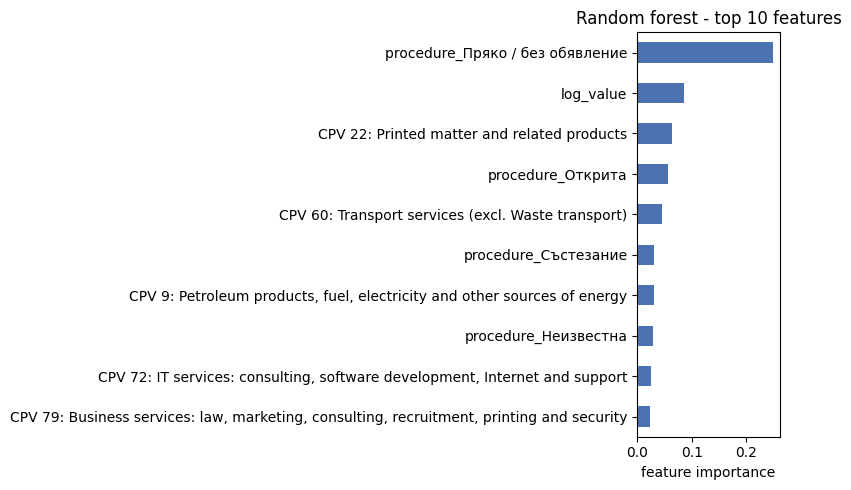

In [6]:
# Map sector_code dummies to official CPV names (display only). Labels from notebook 00.
ref = pd.read_csv("../data/reference/cpv_sectors.csv")
labels_en = dict(zip(ref.sector_code, ref.label_en))

def pretty(feat):
    if feat.startswith("sector_code_"):
        code = int(float(feat.removeprefix("sector_code_")))
        return f"CPV {code}: {labels_en[code]}"
    return feat

importances = pd.Series(f_with.feature_importances_,
                        index=build_features(modelling)[0].columns)

# Integrity check: every sector code present must have an official label.
codes = {int(float(f.removeprefix("sector_code_")))
         for f in importances.index if f.startswith("sector_code_")}
missing = sorted(codes - set(labels_en))
assert not missing, f"Sector codes with no official CPV label: {missing}"

importances.index = importances.index.map(pretty)
top = importances.sort_values(ascending=False).head(10)
print(top.round(3).to_string())

ax = top.sort_values().plot(kind="barh", figsize=(8, 5), color="#4C72B0")
ax.set_xlabel("feature importance")
ax.set_title("Random forest - top 10 features")
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

The direct-award procedure is the single most important feature by a wide
margin (**0.25**, nearly three times the next) - the forest leans on the circular
signal exactly as the logistic coefficients did. After it, the genuine drivers
appear: **contract value** (`log_value`, 0.09), then a spread of **sectors** -
printed matter (CPV 22), transport (CPV 60), petroleum/energy (CPV 9), IT
services (CPV 72) and business services (CPV 79) - interleaved with the
**competitive procedure types** (open and competitive tendering). This
independently confirms Section 4's coefficient story from a completely
different model, and it is the feature narrative carried into the evaluation
section.

## Section 5 - findings & decisions

**Models built and what they showed:**

- **Single decision tree** made the bias-variance tradeoff concrete: depth-5
  underfits (0.65 AUC), depth-10 is better (0.70), unlimited depth overfits hard
  (train acc 0.99 vs test 0.67). This is *why* a single tree is rarely used
  alone.
- **Random forest** is the best model: **ROC-AUC 0.76**, precision ~0.82, with a
  small train/test gap - bagging controlled the variance the deep tree suffered.
- **Gradient boosting** is close behind (0.74).
- **Full spine:** majority 0.50 → logistic 0.71 → boosting 0.74 → forest 0.76.

**Circularity check holds for the forest:** AUC 0.76 with direct awards, 0.72
without - drops but does not collapse, and the forest without direct awards still
beats logistic with them, so the ensemble extracts real extra signal.

**Feature importance** puts the direct-award procedure first by a wide margin
(circularity, at the model level), then contract value and a spread of sectors
(printed matter, transport, petroleum/energy, IT and business services) interleaved
with competitive procedure types - corroborating the Section 4 coefficients from a
different model.

**Decisions:**
- The **random forest is the model to evaluate properly** in the next section
  (cross-validation, the full metric discussion, the confusion matrix and ROC).
- Reporting **with and without direct awards**; the gap is a finding.
- The**feature importance** to be used above as the spine of the evaluation narrative.

**Next (Section 6):** stratified k-fold cross-validation on the
forest, the full precision / recall / F1 / ROC-AUC discussion tied to the triage
use case, and why accuracy alone misleads for a flag like this.